# Integração e Unificação dos Dados

In [4]:
import pandas as pd

# Cargar datasets
patients = pd.read_csv("../data/patients.csv")
diets = pd.read_csv("../data/diets.csv")
nutritionists = pd.read_csv("../data/nutritionists.csv")
outcomes = pd.read_csv("../data/outcomes.csv")

In [5]:
print("PATIENTS")
print(patients.head())
print(patients.columns)
print("\n")

print("DIETS")
print(diets.head())
print(diets.columns)
print("\n")

print("NUTRITIONISTS")
print(nutritionists.head())
print(nutritionists.columns)
print("\n")

print("OUTCOMES")
print(outcomes.head())
print(outcomes.columns)

PATIENTS
  patient_id sex   age  height_cm  baseline_weight_kg  baseline_bmi  smoker  \
0      P0001   F  42.0      155.8                78.1          32.2       0   
1      P0002   F  28.0      162.6                88.2          33.4       0   
2      P0003   F  33.0      160.4                58.9          22.9       0   
3      P0004   F  53.0      172.8                89.4          29.9       1   
4      P0005   F  19.0      169.7                91.1          31.6       1   

   sleep_hours  motivation_score  bmi_redundant record_created_at  
0          4.8               NaN           32.2        2022-01-01  
1          7.8             0.724           33.4        2022-01-02  
2          9.1             0.630           22.9        2022-01-03  
3          8.4             0.393           29.9        2022-01-04  
4          4.6             0.944           31.6        2022-01-05  
Index(['patient_id', 'sex', 'age', 'height_cm', 'baseline_weight_kg',
       'baseline_bmi', 'smoker', 'slee

## Integração dos Dados

In [6]:
# Merge com pacientes
df = outcomes.merge(
    patients,
    on='patient_id',
    how='left'
)

# Merge com dietas
df = df.merge(
    diets,
    on='diet_id',
    how='left'
)

# Merge com nutricionistas
df = df.merge(
    nutritionists,
    on='nutritionist_id',
    how='left'
)

# Visualizar resultado
print(df.head())
print("\nShape final:", df.shape)

  program_id patient_id  program_index nutritionist_id diet_id  \
0    PR00001      P0001              1            N013    D003   
1    PR00002      P0001              2            N014    D002   
2    PR00003      P0001              3            N015    D009   
3    PR00004      P0001              4            N005    D007   
4    PR00005      P0002              1            N013    D007   

   motivation_score_program  mean_adherence_pct  weight_change_kg_6m  \
0                     0.846                85.7                -20.7   
1                     0.892               100.0                -25.6   
2                     0.877                88.7                -24.8   
3                     0.836                91.4                -25.8   
4                     0.816                89.0                -28.1   

   adherence_ratio sex  ...  carb_pct  protein_pct  fat_pct  sodium_limit_mg  \
0            0.857   F  ...        48           21       30           2295.0   
1         

In [7]:
# Verificar duplicados
print("Duplicados:", df.duplicated().sum())

# Valores nulos
print("\nValores nulos:")
print(df.isnull().sum())

Duplicados: 3

Valores nulos:
program_id                    0
patient_id                    0
program_index                 0
nutritionist_id               0
diet_id                       0
motivation_score_program    126
mean_adherence_pct          150
weight_change_kg_6m         151
adherence_ratio             150
sex                           0
age                         143
height_cm                     0
baseline_weight_kg            0
baseline_bmi                  0
smoker                        0
sleep_hours                 200
motivation_score            129
bmi_redundant                 0
record_created_at             0
diet_name                     0
diet_type                     0
carb_pct                      0
protein_pct                   0
fat_pct                       0
sodium_limit_mg             252
fiber_target_g              254
total_macros                  0
approach                    289
years_experience            245
specialty                     0
experience

# Limpeza e Processamento de Dados

## Remoção de Características Redundantes

In [8]:
# Verificar redundancia BMI
print((df['baseline_bmi'] == df['bmi_redundant']).all())

# Verificar redundancia experiencia
print((df['years_experience'] == df['experience_years']).all())

# Comparar adherence
print(df[['mean_adherence_pct', 'adherence_ratio']].head())

False
False
   mean_adherence_pct  adherence_ratio
0                85.7            0.857
1               100.0            1.000
2                88.7            0.887
3                91.4            0.914
4                89.0            0.890


In [9]:
# Estatísticas comparativas do BMI
df[['baseline_bmi', 'bmi_redundant']].describe()

# Diferença máxima entre as variáveis BMI
print(
    "Diferença máxima BMI:",
    (df['baseline_bmi'] - df['bmi_redundant']).abs().max()
)

# Diferença máxima entre variáveis de experiência
print(
    "Diferença máxima experiência:",
    (df['years_experience'] - df['experience_years']).abs().max()
)

Diferença máxima BMI: 9385.5
Diferença máxima experiência: 0.0


In [10]:
# Remover colunas redundantes
df = df.drop(columns=[
    'bmi_redundant',
    'experience_years'
])

# Verificar
print(df.columns)
print("\nNovo shape:", df.shape)

Index(['program_id', 'patient_id', 'program_index', 'nutritionist_id',
       'diet_id', 'motivation_score_program', 'mean_adherence_pct',
       'weight_change_kg_6m', 'adherence_ratio', 'sex', 'age', 'height_cm',
       'baseline_weight_kg', 'baseline_bmi', 'smoker', 'sleep_hours',
       'motivation_score', 'record_created_at', 'diet_name', 'diet_type',
       'carb_pct', 'protein_pct', 'fat_pct', 'sodium_limit_mg',
       'fiber_target_g', 'total_macros', 'approach', 'years_experience',
       'specialty'],
      dtype='object')

Novo shape: (2523, 29)


In [11]:
# Contagem e percentagem de valores nulos
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df)) * 100
})

# Mostrar apenas colunas com missing
missing = missing[missing['Missing Values'] > 0]

missing.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
approach,289,11.454618
fiber_target_g,254,10.067380
sodium_limit_mg,252,9.988109
years_experience,245,9.710662
sleep_hours,200,7.927071
weight_change_kg_6m,151,5.984939
mean_adherence_pct,150,5.945303
adherence_ratio,150,5.945303
age,143,5.667856
motivation_score,129,5.112961


In [12]:
df = df.drop(columns=['adherence_ratio'])

print(df.shape)

(2523, 28)


In [13]:
# Imputação de variáveis numéricas com mediana
numeric_cols = [
    'fiber_target_g',
    'sodium_limit_mg',
    'years_experience',
    'sleep_hours',
    'weight_change_kg_6m',
    'mean_adherence_pct',
    'age',
    'motivation_score',
    'motivation_score_program'
]

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Imputação de variável categórica com moda
df['approach'].fillna(df['approach'].mode()[0], inplace=True)

# Verificar missing values restantes
print(df.isnull().sum())

program_id                  0
patient_id                  0
program_index               0
nutritionist_id             0
diet_id                     0
motivation_score_program    0
mean_adherence_pct          0
weight_change_kg_6m         0
sex                         0
age                         0
height_cm                   0
baseline_weight_kg          0
baseline_bmi                0
smoker                      0
sleep_hours                 0
motivation_score            0
record_created_at           0
diet_name                   0
diet_type                   0
carb_pct                    0
protein_pct                 0
fat_pct                     0
sodium_limit_mg             0
fiber_target_g              0
total_macros                0
approach                    0
years_experience            0
specialty                   0
dtype: int64


C:\Users\kevin\AppData\Local\Temp\ipykernel_22016\2069202292.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\kevin\AppData\Local\Temp\ipykernel_22016\2069202292.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [14]:
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['approach'] = df['approach'].fillna(df['approach'].mode()[0])

## Deteção e Tratamento de Outliers

In [18]:
# Selecionar colunas numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df.describe()

,program_index,motivation_score_program,mean_adherence_pct,weight_change_kg_6m,age,height_cm,baseline_weight_kg,baseline_bmi,smoker,sleep_hours,motivation_score,carb_pct,protein_pct,fat_pct,sodium_limit_mg,fiber_target_g,total_macros,years_experience
count,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000
mean,2.010105,0.714945,78.239284,-21.799789,43.983158,168.745895,75.273937,26.504842,0.240421,7.013937,0.717677,39.728842,29.721263,33.568842,2117.904842,28.844632,103.018947,12.764632
std,1.004991,0.162292,14.457255,7.779434,14.546954,9.070362,10.474287,3.653095,0.427429,1.169798,0.157294,17.178769,8.822013,6.373072,147.901175,4.244609,9.021927,6.259464
min,1.000000,0.082000,20.900000,-100.000000,18.000000,145.400000,54.500000,19.000000,0.000000,4.000000,0.152000,18.000000,17.000000,25.000000,1794.000000,22.000000,93.000000,2.000000
25%,1.000000,0.615000,69.800000,-26.500000,32.000000,162.200000,66.200000,23.500000,0.000000,6.300000,0.622000,29.000000,21.000000,30.000000,2023.000000,26.000000,98.000000,7.000000
50%,2.000000,0.735000,79.900000,-21.600000,43.000000,168.300000,74.800000,26.300000,0.000000,7.000000,0.746500,32.000000,33.000000,30.000000,2166.000000,28.000000,100.000000,13.000000
75%,3.000000,0.837000,89.000000,-16.900000,57.000000,175.300000,83.100000,29.200000,0.000000,7.800000,0.842500,51.000000,39.000000,42.000000,2213.000000,31.000000,103.000000,19.000000
max,4.000000,1.000000,100.000000,100.000000,69.000000,197.900000,102.500000,36.000000,1.000000,10.000000,0.994000,73.000000,41.000000,46.000000,2295.000000,39.000000,124.000000,23.000000


In [19]:
# Função para detectar outliers usando IQR
def count_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    return len(outliers)

# Contar outliers por coluna numérica
for col in numeric_df.columns:
    print(f"{col}: {count_outliers(col)} outliers")

program_index: 0 outliers
motivation_score_program: 34 outliers
mean_adherence_pct: 36 outliers
weight_change_kg_6m: 16 outliers
age: 0 outliers
height_cm: 5 outliers
baseline_weight_kg: 0 outliers
baseline_bmi: 0 outliers
smoker: 571 outliers
sleep_hours: 29 outliers
motivation_score: 40 outliers
carb_pct: 0 outliers
protein_pct: 0 outliers
fat_pct: 0 outliers
sodium_limit_mg: 0 outliers
fiber_target_g: 238 outliers
total_macros: 459 outliers
years_experience: 0 outliers


In [20]:
# Remover registos com valores inválidos

df = df[
    (df['age'] >= 10) & (df['age'] <= 100) &
    (df['height_cm'] >= 120) & (df['height_cm'] <= 250) &
    (df['baseline_weight_kg'] >= 30) & (df['baseline_weight_kg'] <= 300) &
    (df['sleep_hours'] >= 0) & (df['sleep_hours'] <= 24) &
    (df['mean_adherence_pct'] >= 0) & (df['mean_adherence_pct'] <= 100) &
    (df['motivation_score'] >= 0) & (df['motivation_score'] <= 1) &
    (df['motivation_score_program'] >= 0) & (df['motivation_score_program'] <= 1) &
    (df['years_experience'] >= 0) & (df['years_experience'] <= 60)
]

print("Novo shape:", df.shape)

Novo shape: (2375, 28)


## Normalização dos Dados

In [21]:
from sklearn.preprocessing import StandardScaler

# Colunas numéricas para normalização
numeric_cols = [
    'program_index',
    'motivation_score_program',
    'mean_adherence_pct',
    'weight_change_kg_6m',
    'age',
    'height_cm',
    'baseline_weight_kg',
    'baseline_bmi',
    'sleep_hours',
    'motivation_score',
    'carb_pct',
    'protein_pct',
    'fat_pct',
    'sodium_limit_mg',
    'fiber_target_g',
    'total_macros',
    'years_experience'
]

# Criar scaler
scaler = StandardScaler()

# Criar cópia do dataset
df_normalized = df.copy()

# Aplicar normalização
df_normalized[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Visualizar resultado
df_normalized.head()

,program_id,patient_id,program_index,nutritionist_id,diet_id,motivation_score_program,mean_adherence_pct,weight_change_kg_6m,sex,age,...,diet_type,carb_pct,protein_pct,fat_pct,sodium_limit_mg,fiber_target_g,total_macros,approach,years_experience,specialty
0,PR00001,P0001,-1.005300,N013,D003,0.807694,0.516162,0.141401,F,-0.136357,...,balanced,0.481577,-0.988788,-0.560106,1.197641,0.743539,-0.445558,data_driven,-1.560307,sports
1,PR00002,P0001,-0.010057,N014,D002,1.091193,1.505493,-0.488597,F,-0.136357,...,balanced,0.656248,-1.102165,-0.246219,0.643100,-0.434674,-0.002101,empathetic,0.037610,sports
2,PR00003,P0001,0.985186,N015,D009,0.998747,0.723714,-0.385740,F,-0.136357,...,high_protein,-0.624672,1.165369,-0.089276,0.548422,-0.670316,-0.112965,Strict,1.475736,sports
3,PR00004,P0001,1.980429,N005,D007,0.746063,0.910511,-0.514312,F,-0.136357,...,high_protein,-0.566449,1.051992,-0.717049,0.325253,-0.199031,-0.556423,strict,0.996360,weight_loss
4,PR00005,P0002,-1.005300,N013,D007,0.622803,0.744469,-0.810025,F,-1.098960,...,high_protein,-0.566449,1.051992,-0.717049,0.325253,-0.199031,-0.556423,data_driven,-1.560307,sports


### Conclusão

Após o processo de limpeza e processamento dos dados, o conjunto de dados ficou consistente, sem valores em falta, sem características redundantes e sem registos inválidos. Posteriormente, foi aplicada normalização às variáveis numéricas, preparando o dataset para as etapas de análise exploratória e modelação preditiva.

In [22]:
print("Shape final do dataset limpo:", df.shape)
print("Shape do dataset normalizado:", df_normalized.shape)

Shape final do dataset limpo: (2375, 28)
Shape do dataset normalizado: (2375, 28)


# Análise Exploratória de Dados

## Estatísticas Descritivas

In [23]:
# Estatísticas descritivas das variáveis numéricas
df.describe()

,program_index,motivation_score_program,mean_adherence_pct,weight_change_kg_6m,age,height_cm,baseline_weight_kg,baseline_bmi,smoker,sleep_hours,motivation_score,carb_pct,protein_pct,fat_pct,sodium_limit_mg,fiber_target_g,total_macros,years_experience
count,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000,2375.000000
mean,2.010105,0.714945,78.239284,-21.799789,43.983158,168.745895,75.273937,26.504842,0.240421,7.013937,0.717677,39.728842,29.721263,33.568842,2117.904842,28.844632,103.018947,12.764632
std,1.004991,0.162292,14.457255,7.779434,14.546954,9.070362,10.474287,3.653095,0.427429,1.169798,0.157294,17.178769,8.822013,6.373072,147.901175,4.244609,9.021927,6.259464
min,1.000000,0.082000,20.900000,-100.000000,18.000000,145.400000,54.500000,19.000000,0.000000,4.000000,0.152000,18.000000,17.000000,25.000000,1794.000000,22.000000,93.000000,2.000000
25%,1.000000,0.615000,69.800000,-26.500000,32.000000,162.200000,66.200000,23.500000,0.000000,6.300000,0.622000,29.000000,21.000000,30.000000,2023.000000,26.000000,98.000000,7.000000
50%,2.000000,0.735000,79.900000,-21.600000,43.000000,168.300000,74.800000,26.300000,0.000000,7.000000,0.746500,32.000000,33.000000,30.000000,2166.000000,28.000000,100.000000,13.000000
75%,3.000000,0.837000,89.000000,-16.900000,57.000000,175.300000,83.100000,29.200000,0.000000,7.800000,0.842500,51.000000,39.000000,42.000000,2213.000000,31.000000,103.000000,19.000000
max,4.000000,1.000000,100.000000,100.000000,69.000000,197.900000,102.500000,36.000000,1.000000,10.000000,0.994000,73.000000,41.000000,46.000000,2295.000000,39.000000,124.000000,23.000000


## Análise de Correlação

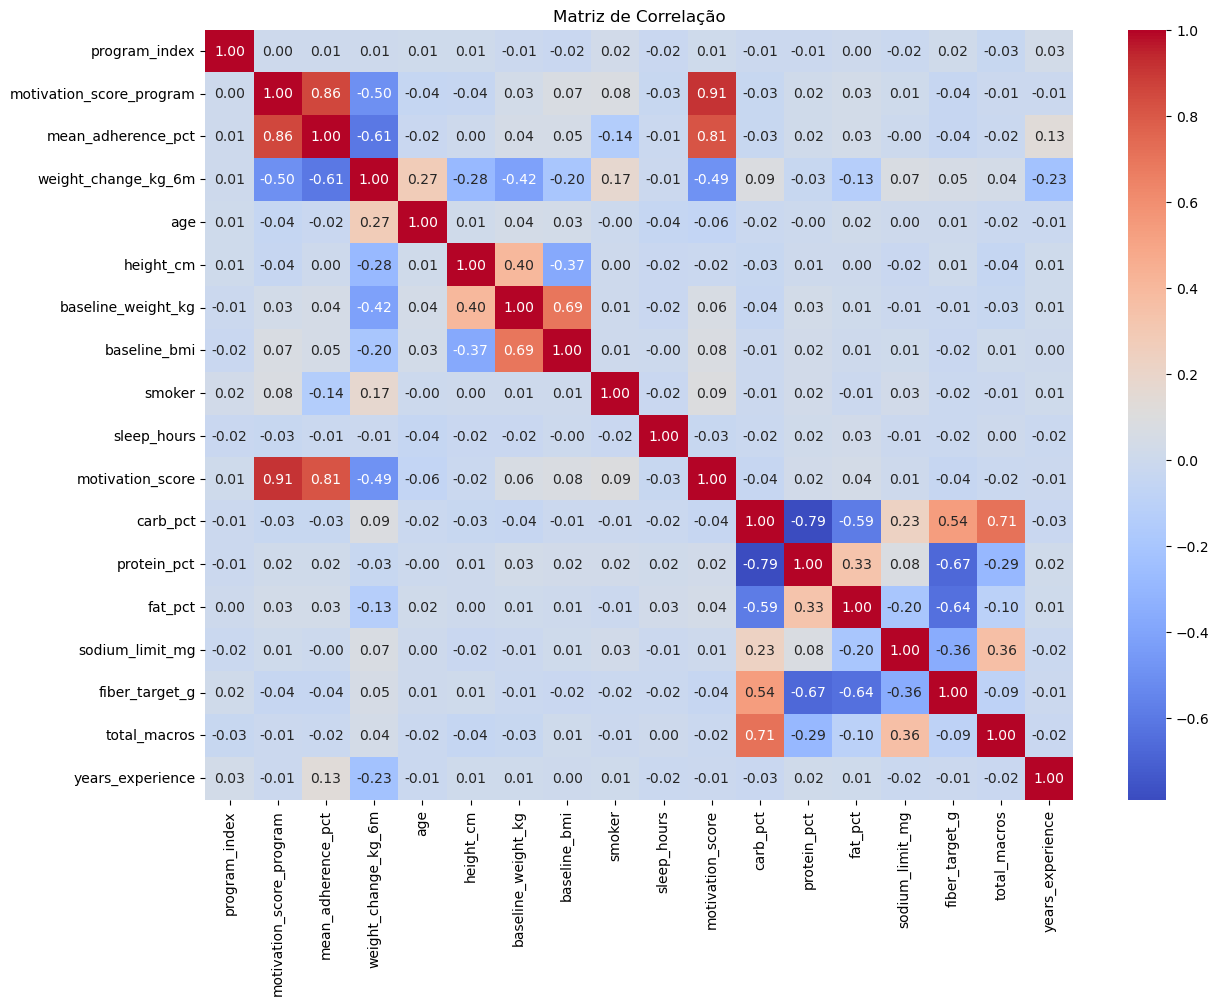

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlação entre variáveis numéricas
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Matriz de Correlação')
plt.show()

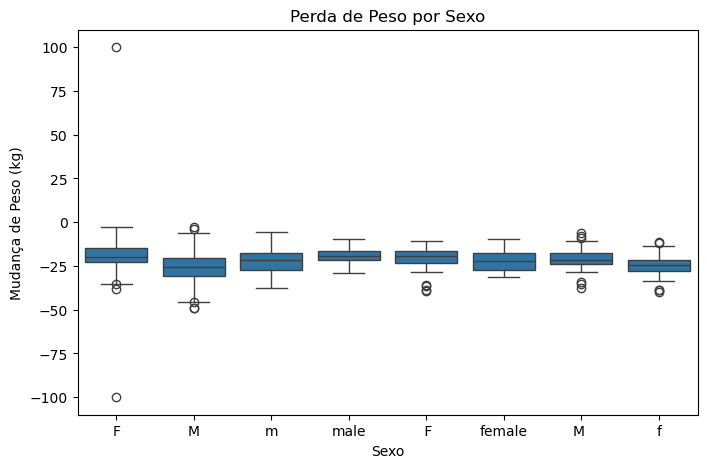

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='sex',
    y='weight_change_kg_6m',
    data=df
)

plt.title('Perda de Peso por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Mudança de Peso (kg)')

plt.show()

In [26]:
# Padronizar categorias de sexo
df['sex'] = df['sex'].replace({
    'm': 'M',
    'male': 'M',
    'f': 'F',
    'female': 'F'
})

# Verificar categorias
print(df['sex'].value_counts())

sex
F     1238
M     1052
M       45
 F      40
Name: count, dtype: int64


In [27]:
# Remover espaços em branco
df['sex'] = df['sex'].str.strip()

# Verificar novamente
print(df['sex'].value_counts())

sex
F    1278
M    1097
Name: count, dtype: int64


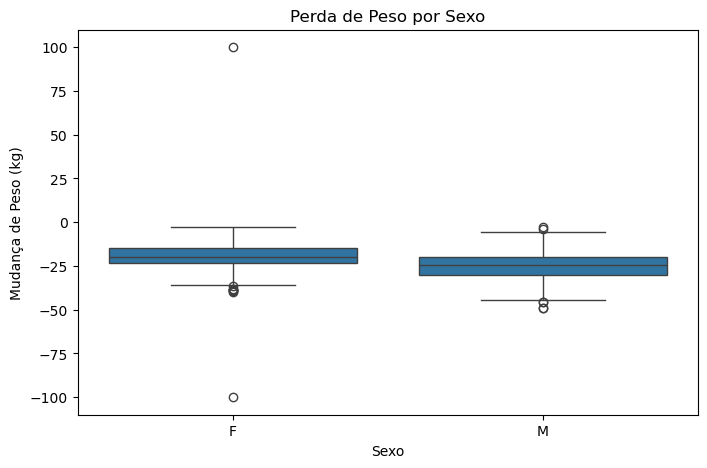

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='sex',
    y='weight_change_kg_6m',
    data=df
)

plt.title('Perda de Peso por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Mudança de Peso (kg)')

plt.show()

### Influência do Tipo de Dieta nos Resultados Clínicos

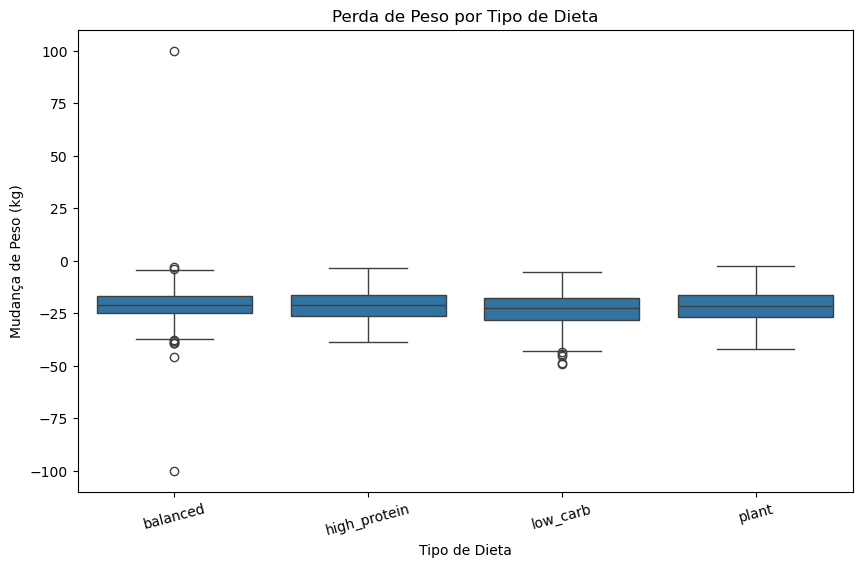

In [29]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x='diet_type',
    y='weight_change_kg_6m',
    data=df
)

plt.title('Perda de Peso por Tipo de Dieta')
plt.xlabel('Tipo de Dieta')
plt.ylabel('Mudança de Peso (kg)')

plt.xticks(rotation=15)

plt.show()

### Influência do Perfil do Nutricionista

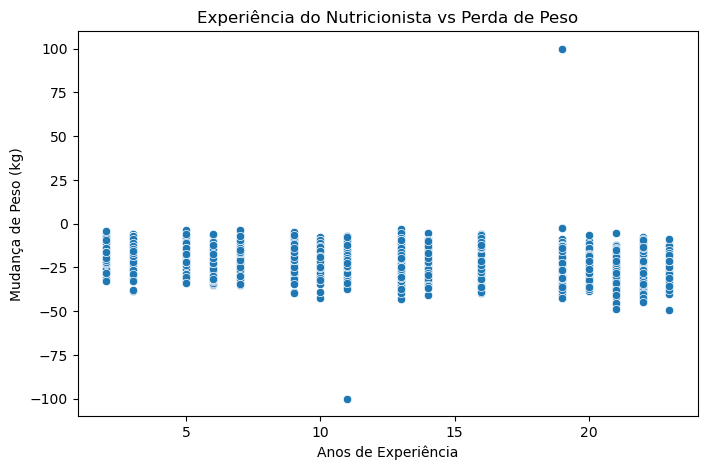

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='years_experience',
    y='weight_change_kg_6m',
    data=df
)

plt.title('Experiência do Nutricionista vs Perda de Peso')
plt.xlabel('Anos de Experiência')
plt.ylabel('Mudança de Peso (kg)')

plt.show()

### Relação entre Adesão à Dieta e Resultados Clínicos

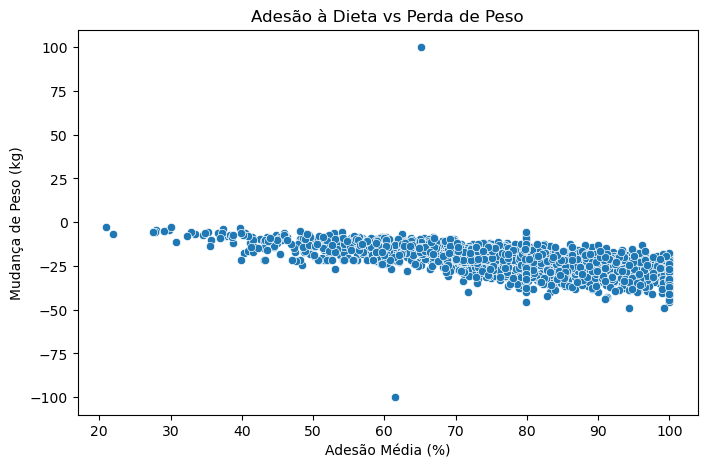

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='mean_adherence_pct',
    y='weight_change_kg_6m',
    data=df
)

plt.title('Adesão à Dieta vs Perda de Peso')
plt.xlabel('Adesão Média (%)')
plt.ylabel('Mudança de Peso (kg)')

plt.show()

# Identificação de Padrões com Clustering

## Seleção das Variáveis para Clustering

In [32]:
# Seleção de variáveis numéricas relevantes
cluster_features = [
    'motivation_score_program',
    'mean_adherence_pct',
    'weight_change_kg_6m',
    'age',
    'baseline_bmi',
    'sleep_hours',
    'motivation_score',
    'carb_pct',
    'protein_pct',
    'fat_pct',
    'fiber_target_g',
    'years_experience'
]

# Dataset para clustering
X_cluster = df_normalized[cluster_features]

print(X_cluster.head())
print("\nShape:", X_cluster.shape)

   motivation_score_program  mean_adherence_pct  weight_change_kg_6m  \
0                  0.807694            0.516162             0.141401   
1                  1.091193            1.505493            -0.488597   
2                  0.998747            0.723714            -0.385740   
3                  0.746063            0.910511            -0.514312   
4                  0.622803            0.744469            -0.810025   

        age  baseline_bmi  sleep_hours  motivation_score  carb_pct  \
0 -0.136357      1.559324    -1.892978          0.183279  0.481577   
1 -0.136357      1.559324    -1.892978          0.183279  0.656248   
2 -0.136357      1.559324    -1.892978          0.183279 -0.624672   
3 -0.136357      1.559324    -1.892978          0.183279 -0.566449   
4 -1.098960      1.887881     0.672106          0.040204 -0.566449   

   protein_pct   fat_pct  fiber_target_g  years_experience  
0    -0.988788 -0.560106        0.743539         -1.560307  
1    -1.102165 -0.246219

## Determinação do Número Ideal de Clusters

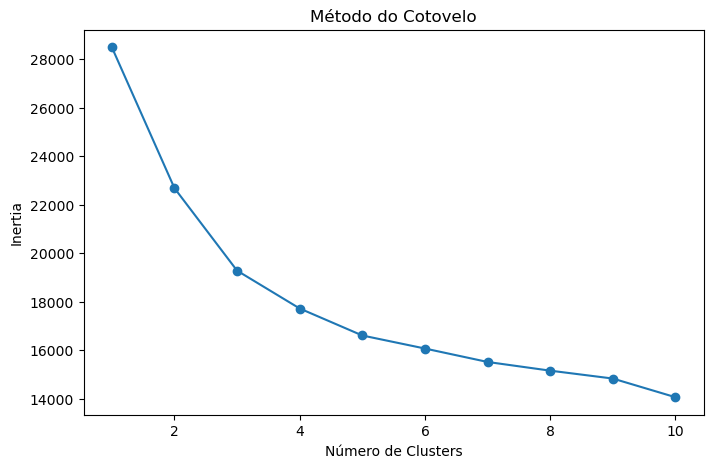

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista para armazenar inertia
inertia = []

# Testar diferentes números de clusters
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.title('Método do Cotovelo')
plt.xlabel('Número de Clusters')
plt.ylabel('Inertia')

plt.show()

## Aplicação do Algoritmo K-Means

In [34]:
# Aplicar K-Means com 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

# Criar clusters
df['cluster'] = kmeans.fit_predict(X_cluster)

# Ver distribuição dos clusters
print(df['cluster'].value_counts())

cluster
0    1026
2     805
1     544
Name: count, dtype: int64


## Análise dos Clusters

In [35]:
# Média das variáveis por cluster
cluster_analysis = df.groupby('cluster')[cluster_features].mean()

cluster_analysis


,motivation_score_program,mean_adherence_pct,weight_change_kg_6m,age,baseline_bmi,sleep_hours,motivation_score,carb_pct,protein_pct,fat_pct,fiber_target_g,years_experience
cluster,,,,,,,,,,,,
0,0.789819,84.960429,-24.907797,43.351852,26.726608,7.012378,0.791904,26.917154,36.578947,36.870370,26.419103,13.201754
1,0.502188,59.216544,-14.283640,45.840074,25.961029,7.116360,0.511029,36.869485,31.588235,33.922794,28.049632,12.012868
2,0.763293,82.528075,-22.917764,43.532919,26.589689,6.946708,0.762722,57.990062,19.719255,29.121739,32.473292,12.715528


## Definição da Variável Objetivo

In [36]:
# Variável alvo
y = df['weight_change_kg_6m']

# Features
X = df.drop(columns=[
    'weight_change_kg_6m',
    'program_id',
    'patient_id',
    'nutritionist_id',
    'diet_id',
    'record_created_at'
])

print(X.head())
print("\nTarget:")
print(y.head())

   program_index  motivation_score_program  mean_adherence_pct sex   age  \
0              1                     0.846                85.7   F  42.0   
1              2                     0.892               100.0   F  42.0   
2              3                     0.877                88.7   F  42.0   
3              4                     0.836                91.4   F  42.0   
4              1                     0.816                89.0   F  28.0   

   height_cm  baseline_weight_kg  baseline_bmi  smoker  sleep_hours  ...  \
0      155.8                78.1          32.2       0          4.8  ...   
1      155.8                78.1          32.2       0          4.8  ...   
2      155.8                78.1          32.2       0          4.8  ...   
3      155.8                78.1          32.2       0          4.8  ...   
4      162.6                88.2          33.4       0          7.8  ...   

   carb_pct protein_pct fat_pct  sodium_limit_mg  fiber_target_g  \
0        48       

## Codificação das Variáveis Categóricas

In [37]:
# Aplicar One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=[
        'sex',
        'diet_name',
        'diet_type',
        'approach',
        'specialty',
        'cluster'
    ],
    drop_first=True
)

print(X_encoded.head())
print("\nShape:", X_encoded.shape)

   program_index  motivation_score_program  mean_adherence_pct   age  \
0              1                     0.846                85.7  42.0   
1              2                     0.892               100.0  42.0   
2              3                     0.877                88.7  42.0   
3              4                     0.836                91.4  42.0   
4              1                     0.816                89.0  28.0   

   height_cm  baseline_weight_kg  baseline_bmi  smoker  sleep_hours  \
0      155.8                78.1          32.2       0          4.8   
1      155.8                78.1          32.2       0          4.8   
2      155.8                78.1          32.2       0          4.8   
3      155.8                78.1          32.2       0          4.8   
4      162.6                88.2          33.4       0          7.8   

   motivation_score  ...  approach_data_driven  approach_empathetic  \
0            0.7465  ...                  True                False  

## Divisão dos Dados em Treino, Validação e Teste

In [38]:
from sklearn.model_selection import train_test_split

# Primeiro split: treino e temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded,
    y,
    test_size=0.30,
    random_state=42
)

# Segundo split: validação e teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Verificar shapes
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (1662, 40)
Validação: (356, 40)
Teste: (357, 40)


## Treino do Modelo de Regressão Linear

In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Criar modelo
lr_model = LinearRegression()

# Treinar
lr_model.fit(X_train, y_train)

# Previsões
y_val_pred_lr = lr_model.predict(X_val)

# Métricas
mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))
r2_lr = r2_score(y_val, y_val_pred_lr)

# Resultados
print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 2.0642992092708594
RMSE: 2.801181968509472
R²: 0.851252464402587


## Treino do Modelo Decision Tree Regressor

In [40]:
from sklearn.tree import DecisionTreeRegressor

# Criar modelo
dt_model = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

# Treinar
dt_model.fit(X_train, y_train)

# Previsões
y_val_pred_dt = dt_model.predict(X_val)

# Métricas
mae_dt = mean_absolute_error(y_val, y_val_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_val, y_val_pred_dt))
r2_dt = r2_score(y_val, y_val_pred_dt)

# Resultados
print("Decision Tree Regressor")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R²:", r2_dt)

Decision Tree Regressor
MAE: 3.040360331502491
RMSE: 3.8786162856259847
R²: 0.7148188812911892


## Treino do Modelo Random Forest Regressor

In [41]:
from sklearn.ensemble import RandomForestRegressor

# Criar modelo
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=10
)

# Treinar
rf_model.fit(X_train, y_train)

# Previsões
y_val_pred_rf = rf_model.predict(X_val)

# Métricas
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_val_pred_rf))
r2_rf = r2_score(y_val, y_val_pred_rf)

# Resultados
print("Random Forest Regressor")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Regressor
MAE: 2.083944003058535
RMSE: 2.7522258846463967
R²: 0.8564063333982811


## Importância das Características

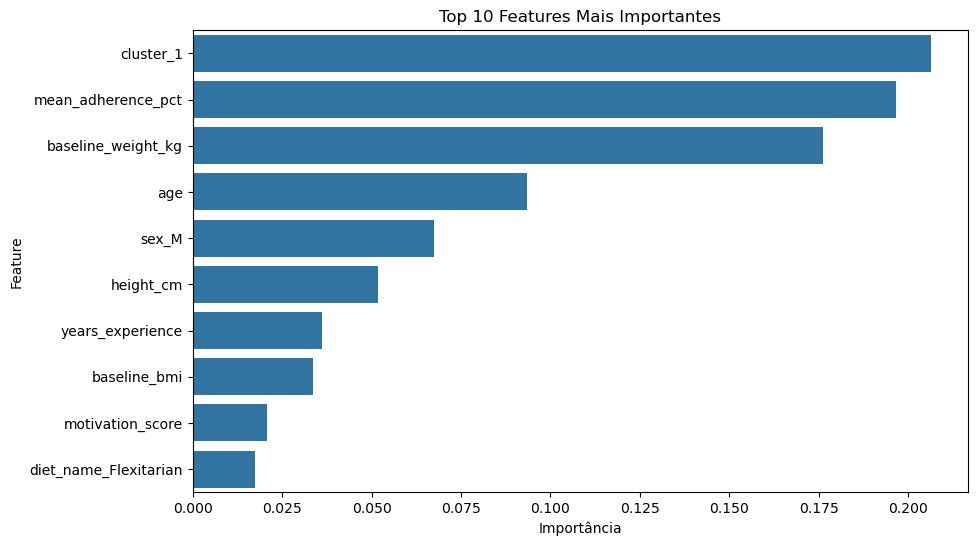

,Feature,Importance
38,cluster_1,0.206333
2,mean_adherence_pct,0.196548
5,baseline_weight_kg,0.176286
3,age,0.093375
17,sex_M,0.067533
4,height_cm,0.051847
16,years_experience,0.036093
6,baseline_bmi,0.033579
9,motivation_score,0.020681
20,diet_name_Flexitarian,0.017511


In [42]:
# Importância das features
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
})

# Ordenar
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 10
top_features = feature_importance.head(10)

# Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Features Mais Importantes')
plt.xlabel('Importância')
plt.ylabel('Feature')

plt.show()

# Mostrar tabela
top_features

# Discussão Crítica dos Resultados

In [43]:
# Comparação dos modelos
results = pd.DataFrame({
    'Modelo': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],
    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf
    ],
    'R²': [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

results

,Modelo,MAE,RMSE,R²
0,Linear Regression,2.064299,2.801182,0.851252
1,Decision Tree Regressor,3.040360,3.878616,0.714819
2,Random Forest Regressor,2.083944,2.752226,0.856406


### Interpretação dos Resultados

O modelo Random Forest apresentou o melhor desempenho global, enquanto a Regressão Linear obteve resultados bastante semelhantes, sugerindo relações predominantemente lineares entre as variáveis do dataset.